# General notebook

In [148]:
using Revise
Revise.retry() # Just in case if only Revise is not sufficient. 
include("lattice_protein.jl")

Imports done, importing hamiltonian path
hamiltonian path imported, importing metropolis
metropolis imported, importing benchmark
benchmark imported, importing visualization
visualization imported, importing tree
tree imported, importing lattice_protein


## Hamiltonian paths

In [2]:
println("We find $(length(PATHS)) unique paths.")
println(first(PATHS))

We find 103346 unique paths.
Int8[1, 2, 3, 6, 5, 4, 7, 8, 9, 18, 17, 16, 13, 14, 15, 12, 11, 10, 19, 20, 21, 24, 23, 22, 25, 26, 27]


Contact map for the first path:
Path visualization for the 75005:


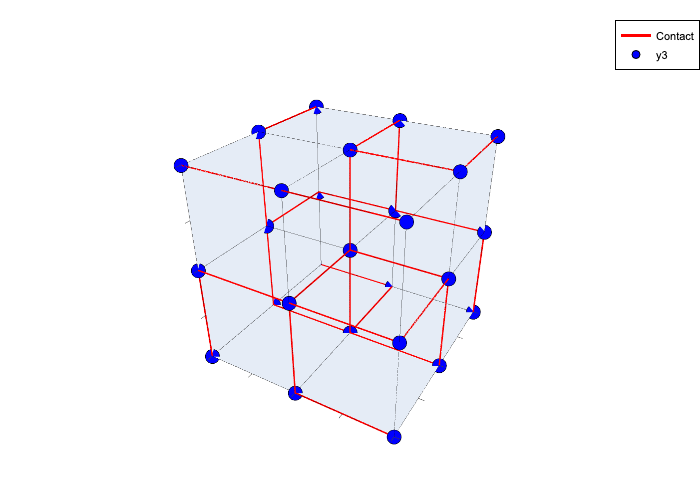

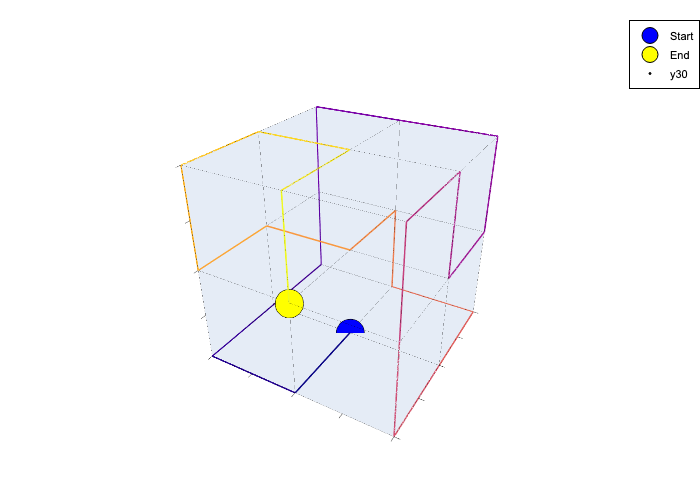

In [3]:
println("Contact map for the first path:")
liste_contact = contact_map(PATHS[75005])
display(plot_cube_ctc_map(x, y, z, lx, ly, lz, liste_contact))

println("Path visualization for the 75005:")
display(plot_cube_path(x, y, z, lx, ly, lz, PATHS[75005]))

## Metropolis general results

Attention : si on veut changer de matrice (MJ*5 ou MJ_1996) il faut restart le kernel et modifier la ligne const dans le ficher metropolis.jl. 

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:01:10


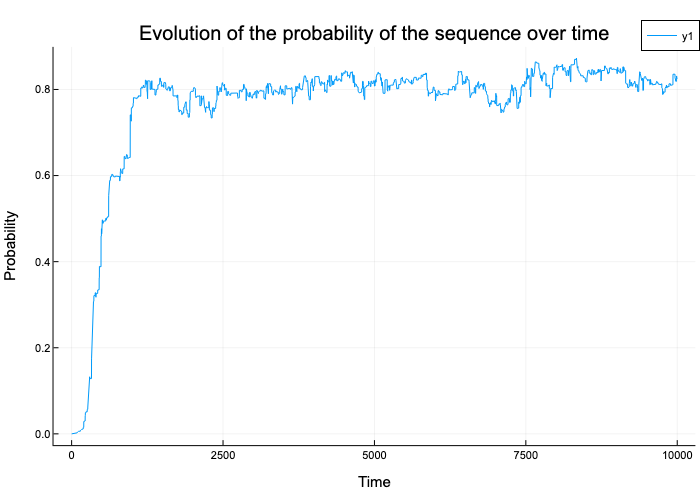

In [4]:
# with all the data
seq = generate_seq()
print(matrix_name)
target_number = 75005
all_ctc_maps = all_contact_maps(PATHS)
plot_probability(seq, target_number, all_ctc_maps, 10000)

MJ*5

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


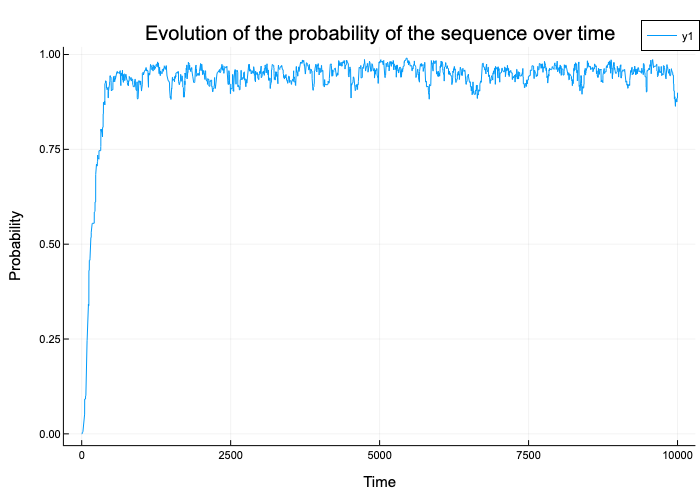

In [5]:
# with few data
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
print(matrix_name)

all_ctc_maps = all_contact_maps(paths_reduced)
plot_probability(seq, target_number, all_ctc_maps, 10000)

Testing beta = 10


algo (β=10) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 50


algo (β=50) 100%|████████████████████████████████████████| Time: 0:00:02


Testing beta = 100


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:02


Testing beta = 1000


algo (β=1000) 100%|██████████████████████████████████████| Time: 0:00:02


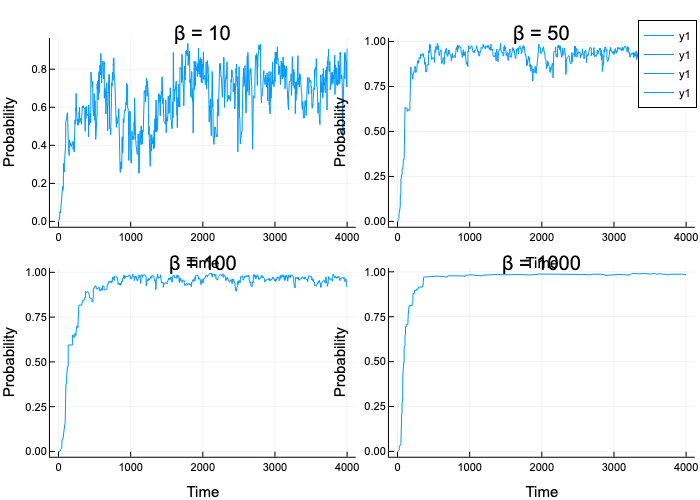

Dict{Float64, Tuple{Vector{Int64}, Vector{Float64}}} with 4 entries:
  50.0   => ([8, 18, 13, 15, 15, 4, 19, 9, 14, 16  …  14, 12, 2, 17, 4, 12, 5, …
  10.0   => ([6, 15, 19, 19, 18, 10, 16, 6, 19, 9  …  16, 2, 19, 16, 4, 15, 5, …
  1000.0 => ([20, 4, 14, 5, 11, 1, 6, 16, 18, 5  …  15, 4, 16, 18, 19, 18, 4, 1…
  100.0  => ([2, 19, 16, 15, 16, 8, 19, 1, 15, 14  …  19, 16, 16, 18, 1, 14, 3,…

In [6]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)


benchmark_beta()

## Further observations

### Chain evolution

ici

Multi-init 100%|█████████████████████████████████████████| Time: 0:00:22


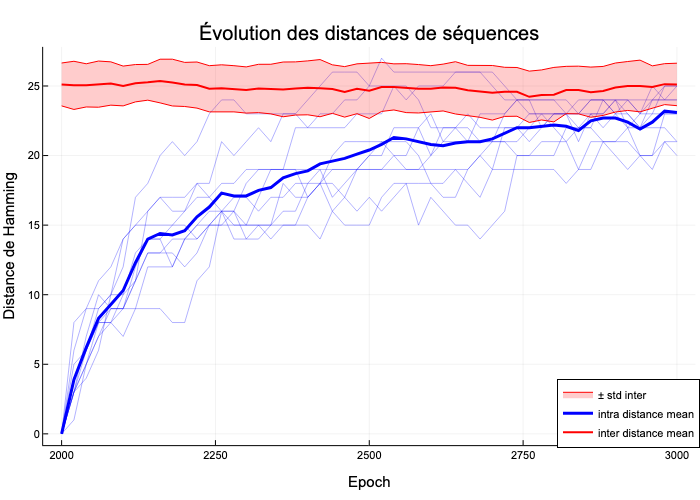

In [7]:
paths_reduced = reduce_data(PATHS, 10)
beta = 100.0

seq_over_time = multi_init_seq_over_time(target_number, all_ctc_maps, epochs=3000, beta=beta, threshold=2000, step=20, runs=10)
plot_distances_inter_intra(seq_over_time, beta=beta)

### All proba

In [8]:
final_seq, p_struct_time_t, p_final,_=algo_show_probability_distribution(seq, target_number, all_ctc_maps, 10000, 100)
show_sorted_indices(p_final)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


structure 1234 : 0.977825228799678
structure 1271 : 0.00626720794353904
structure 529 : 0.001795585138744262
structure 2332 : 0.0013984031121253714
structure 570 : 0.0010890774387727598
structure 1233 : 0.0010890774387727349
structure 1797 : 0.00103596250532051
structure 518 : 0.0008481743621416149
structure 9809 : 0.0008481743621416045
structure 532 : 0.0007674598998845335
structure 10031 : 0.0005976983710059494
structure 557 : 0.0005144437554211004
structure 1207 : 0.0004211909232921765
structure 1237 : 0.0004006491995681383
structure 1208 : 0.0003811093075318764
structure 1210 : 0.00032802382088251684
structure 1253 : 0.00026856318989865825
structure 1265 : 0.00019895650448133078
structure 1308 : 0.0001989565044813307
structure 10303 : 0.00019895650448132948


### Mutations on the cube

In [9]:
# Mutations en fonction de la position
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234

all_ctc_maps = all_contact_maps(paths_reduced)

beta = 100

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, 10000, beta, 2000, 200)
println("On a sauvegardé $(length(saved_seq)) structures.")

n_mutations_per_position = amount_of_mutations(saved_seq)
n_mutations_per_position


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


On a sauvegardé 41 structures.


Dict{Int64, Int64} with 27 entries:
  5  => 14
  16 => 10
  20 => 20
  12 => 24
  24 => 29
  8  => 32
  17 => 21
  23 => 31
  1  => 38
  22 => 12
  19 => 31
  6  => 38
  11 => 21
  9  => 14
  14 => 23
  3  => 35
  7  => 25
  25 => 10
  13 => 18
  ⋮  => ⋮

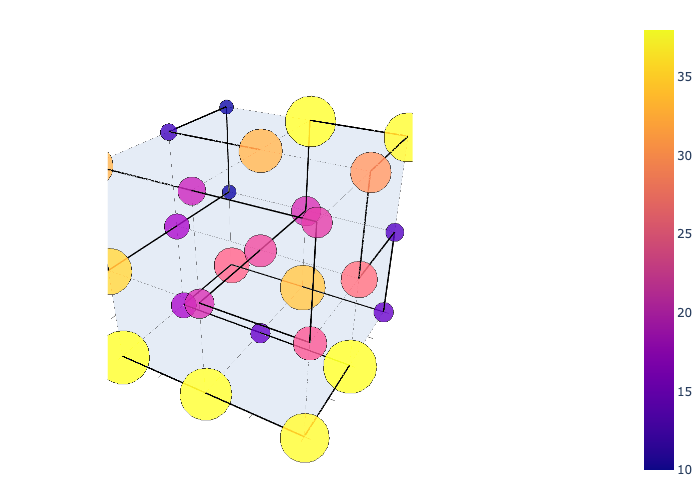

In [10]:
plot_cube_with_mutations_on_sphere(x, y, z, lx, ly, lz, PATHS[target_number], n_mutations_per_position)

In [11]:
beta = 100
target_number = 1234
epoch_start, epoch_stop, step = 2000, 10000, 200

paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
all_ctc_maps = all_contact_maps(paths_reduced)

_, _, saved_seq = algo(seq, target_number, all_ctc_maps, epoch_stop, beta, epoch_start, step)
println("On a sauvegardé $(length(saved_seq)) structures.")

plot_gif_cube_with_mutations(x, y, z, lx, ly, lz, PATHS[target_number], saved_seq)


algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:06


On a sauvegardé 41 structures.


┌ Info: Saved animation to /Users/marie.gabilly/Documents/master/m1/s2/projet/figures/mutations.gif
└ @ Plots /Users/marie.gabilly/.julia/packages/Plots/AE0LB/src/animation.jl:156


GIF sauvegardé : ../figures/mutations.gif


## Tree generation

### Creating the tree

In [92]:
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
beta = 100
number_of_nodes = 3
distance_btw_nodes = 50

root_seq,p_struct_time_t,_ = algo(seq, target_number, all_ctc_maps, 5000, beta, 10000, 200, true)
proba_final_root = p_struct_time_t[end]
println("----------- Generating the root sequence : -----------")
println("Probability of the root sequence: $proba_final_root")
println()

newick, seq_dict = create_genealogy(root_seq, distance_btw_nodes, number_of_nodes, target_number, all_ctc_maps, beta=100 )

println("----------- Generated genealogy : -----------")
println(newick)
println()

# Charger l'arbre dans TreeTools
tree = parse_newick_string(newick)

println("----------- Sequences in the genealogy : -----------")
for node in nodes(tree)
    name = label(node)
    println("$name : " * join([aa_idx[acid] for acid in seq_dict[name]], " "))
end

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


----------- Generating the root sequence : -----------
Probability of the root sequence: 0.9427186176692641

----------- Generated genealogy : -----------
(((N4:50,N5:50)N3:50,(N7:50,N8:50)N6:50)N2:50,((N11:50,N12:50)N10:50,(N14:50,N15:50)N13:50)N9:50)N1;

----------- Sequences in the genealogy : -----------
N1 : GLY VAL ARG ASP PHE ASP LYS CYS PHE LEU LYS ASN ALA GLU ARG LYS CYS MET LEU PHE VAL ARG LEU GLU GLU MET LYS
N6 : THR MET GLU GLU PHE GLU ARG MET LEU CYS GLU ARG GLU GLU LYS LYS CYS ILE VAL MET MET LYS CYS GLU ASP SER ARG
N8 : VAL MET GLU GLU LEU ASN ARG LEU VAL PRO GLU ARG GLU ASP ASN LYS MET PHE ILE PHE ALA LYS ILE GLU TYR ILE LYS
N2 : VAL CYS SER GLU PHE ASP ARG CYS LEU LEU ASP ASN GLU ASP LYS LYS CYS LEU ILE TRP PHE ARG CYS GLU GLU THR ARG
N14 : GLY TYR GLU PRO ILE ASP LYS CYS MET TRP ARG ARG ASP ASP LYS LYS PHE ILE CYS MET ILE LYS PHE ASP ASP VAL LYS
N9 : SER VAL HIS ASP LEU GLU LYS LEU VAL LEU GLU ARG ASP ASP LYS ARG ILE CYS SER PHE LEU ARG ALA GLU ASP CYS SER
N3 : CYS IL

In [93]:
N1= seq_dict["N1"]
N3 = seq_dict["N3"]
println(hamming_distance(N1,N3))

22


In [94]:
simple_print_distance_matrix(seq_dict)

      N1    N6    N8    N2    N14   N9    N3    N11   N4    N7    N12   N13   N15   N10   N5    
N1    0     22    23    17    21    20    22    24    22    23    25    23    20    24    21    
N6    22    0     17    16    19    21    19    20    18    14    19    20    19    20    19    
N8    23    17    0     19    21    19    17    22    23    17    21    23    22    21    20    
N2    17    16    19    0     22    22    14    20    16    20    23    22    21    20    16    
N14   21    19    21    22    0     21    21    21    25    21    17    16    20    17    19    
N9    20    21    19    22    21    0     20    21    23    21    18    17    18    17    19    
N3    22    19    17    14    21    20    0     22    15    20    23    23    18    24    14    
N11   24    20    22    20    21    21    22    0     22    20    21    21    22    16    21    
N4    22    18    23    16    25    23    15    22    0     21    24    22    21    24    15    
N7    23    14    17    20    

In [95]:
p = plot_distance_matrix(seq_dict)
savefig(p, "../figures/distance_matrix.svg")

"/Users/marie.gabilly/Documents/master/m1/s2/projet/figures/distance_matrix.svg"

In [96]:
tree


                                                   ________________________ N4
                          ________________________|
                         |                        |________________________ N5
  _______________________|
 |                       |                         ________________________ N7
 |                       |________________________|
 |                                                |________________________ N8
_|
 |                                                 ________________________ N11
 |                        ________________________|
 |                       |                        |________________________ N12
 |_______________________|
                         |                         ________________________ N14
                         |________________________|
                                                  |________________________ N15


### Fitch reconstruction

In [97]:
result_fitch = fitch_reconstruction(tree, seq_dict)

for (name, seq) in sort(collect(result_fitch))
    println("$name : " * join([aa_idx[acid] for acid in seq], " "))
end
println(typeof(result_fitch))

N1 : GLN MET LEU GLU LEU ASP ARG CYS LEU ALA GLU ARG GLU ASP LYS LYS VAL ILE LEU MET LEU LYS CYS GLU ASP LEU LYS
N10 : GLN TYR ASP GLU VAL ASP LYS MET VAL ALA ASP ARG ASP ASP LYS ARG VAL CYS GLY MET LEU LYS VAL ASP ASP VAL LYS
N11 : MET TYR ASN GLN MET ASP ASN MET VAL ALA ASP LYS GLU ASP ARG ARG VAL CYS GLY MET PHE LYS VAL GLU ASP PHE ARG
N12 : GLN MET ASP GLU VAL GLU LYS MET CYS GLU ASP ARG ASP ASP LYS ASN TRP CYS LYS ILE LEU LYS GLY ASP ASP VAL LYS
N13 : GLY TYR ASP GLU VAL ASP LYS CYS MET ALA GLU ARG ASP ASP LYS LYS VAL ILE LEU MET ILE LYS CYS ASP ASP VAL LYS
N14 : GLY TYR GLU PRO ILE ASP LYS CYS MET TRP ARG ARG ASP ASP LYS LYS PHE ILE CYS MET ILE LYS PHE ASP ASP VAL LYS
N15 : ARG GLN ASP GLU VAL GLU LYS ALA PHE ALA GLU LYS ASP ASP LYS LYS VAL VAL LEU PHE MET ARG CYS ASP ASP MET ASP
N2 : TRP MET LEU GLU LEU ASP ARG CYS LEU ALA GLU ARG GLU ASP LYS LYS VAL ILE ALA PHE ALA LYS CYS GLU ASP LEU LYS
N3 : TRP SER LEU GLU LEU ASP ARG CYS LEU THR TRP ARG GLU ASP LYS LYS VAL LEU ALA CYS CYS A

In [115]:
root_name_reconstructed, root_seq_reconstructed = first(sort(collect(result)))
print("$(join([aa_idx[acid] for acid in root_seq_reconstructed], " "))")

TYR ARG ASN ILE ASP HIS ILE ASN ARG GLN ASP ASP CYS VAL VAL CYS GLU GLU ARG PHE PHE CYS TYR LEU CYS GLN PHE

### Consensus from the leaves

In [114]:
n_aa = 20

result_consensus, result_PWM = consensus_from_leaves_reconstruction(tree, seq_dict, n_aa; pseudo_count=1.0)

print("$(join([aa_idx[acid] for acid in result_consensus], " "))")

TRP MET ASN GLU VAL ASP ARG CYS MET ALA GLU ARG GLU ASP LYS LYS VAL CYS ALA PHE CYS LYS CYS GLU ASP LEU LYS

## Reconstruction error

In [149]:
# Result for the reconstruction above
println("Reconstruction Error (Hamming): $(reconstruction_error_hamming(result, seq_dict))")
println("Reconstruction Error (Probability): $(reconstruction_error_prob_folding(result, seq_dict, all_ctc_maps, target_number))")

Reconstruction Error (Hamming): 26
Reconstruction Error (Probability): 0.03586430779116245


In [150]:
# generating values for the reconstruction error plots
distance_btw_nodes = 0:5:40
paths_reduced = reduce_data(PATHS, 10)
seq = generate_seq()
target_number = 1234
all_ctc_maps = all_contact_maps(paths_reduced)
number_of_nodes = 4

root_seq,_,_ = algo(seq, target_number, all_ctc_maps, 5000, 100, 10000, 200, true)

algo (β=100) 100%|███████████████████████████████████████| Time: 0:00:03


([13, 18, 11, 8, 17, 4, 19, 2, 14, 16  …  14, 16, 15, 19, 1, 19, 9, 1, 16, 6], [2.4819804986695888e-6, 2.4819804986695888e-6, 2.7641366287993072e-5, 2.7641366287993072e-5, 0.00042708996506000464, 0.00042708996506000464, 0.00042708996506000464, 0.00042708996506000464, 0.00042708996506000464, 0.00042708996506000464  …  0.9608584975616398, 0.9608584975616398, 0.9609564858035646, 0.9609564858035646, 0.960932803907827, 0.9605666169537643, 0.9605666169537643, 0.9605666169537643, 0.9605666169537643, 0.9605666169537643], Dict{Int64, Vector{Int64}}())

1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 
1 2 3 4 5 6 7 8 9 10 


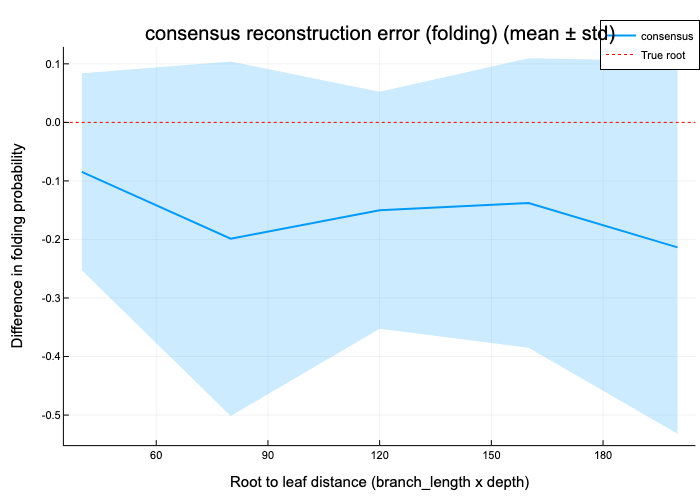

In [151]:
root_to_leaf_distances = [40, 80, 120, 160, 200]  # branch_length × profondeur
tree_depth = 2                                    # branch_length sera 20, 40, 60, 80, 100
n_trees = 10


hamming_fitch = plot_reconstruction_error_hamming(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :fitch)
hamming_consensus = plot_reconstruction_error_hamming(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :consensus)

proba_fitch = plot_reconstruction_error_proba(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :fitch)
proba_consensus = plot_reconstruction_error_proba(root_seq, root_to_leaf_distances, tree_depth, n_trees, target_number, all_ctc_maps, :consensus)

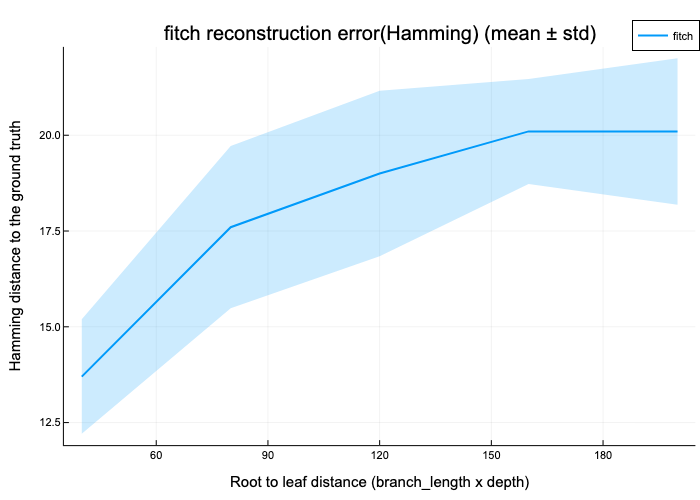

In [152]:
plot(hamming_fitch)


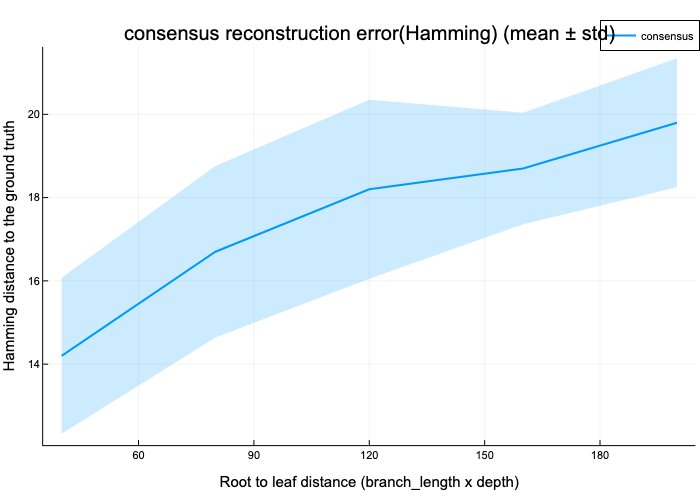

In [153]:
plot(hamming_consensus)


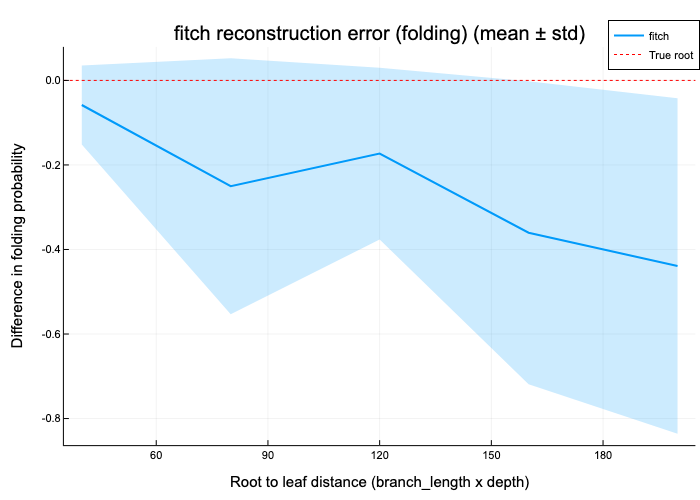

In [154]:
plot(proba_fitch)


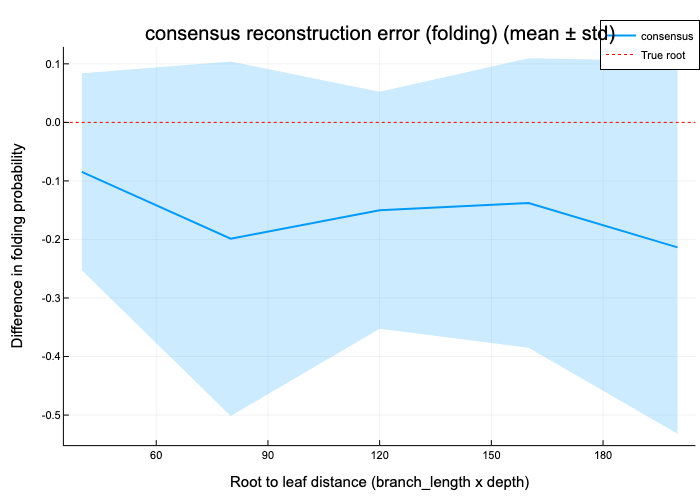

In [155]:
plot(proba_consensus)